--- Starting Feature Engineering: Cotton Futures Base ---
Calculating Log Returns, Volatility, and Momentum indicators...
Notice: 'Open Interest' column not found. Skipping OI_ROC calculation.
Generating diagnostic graphs...


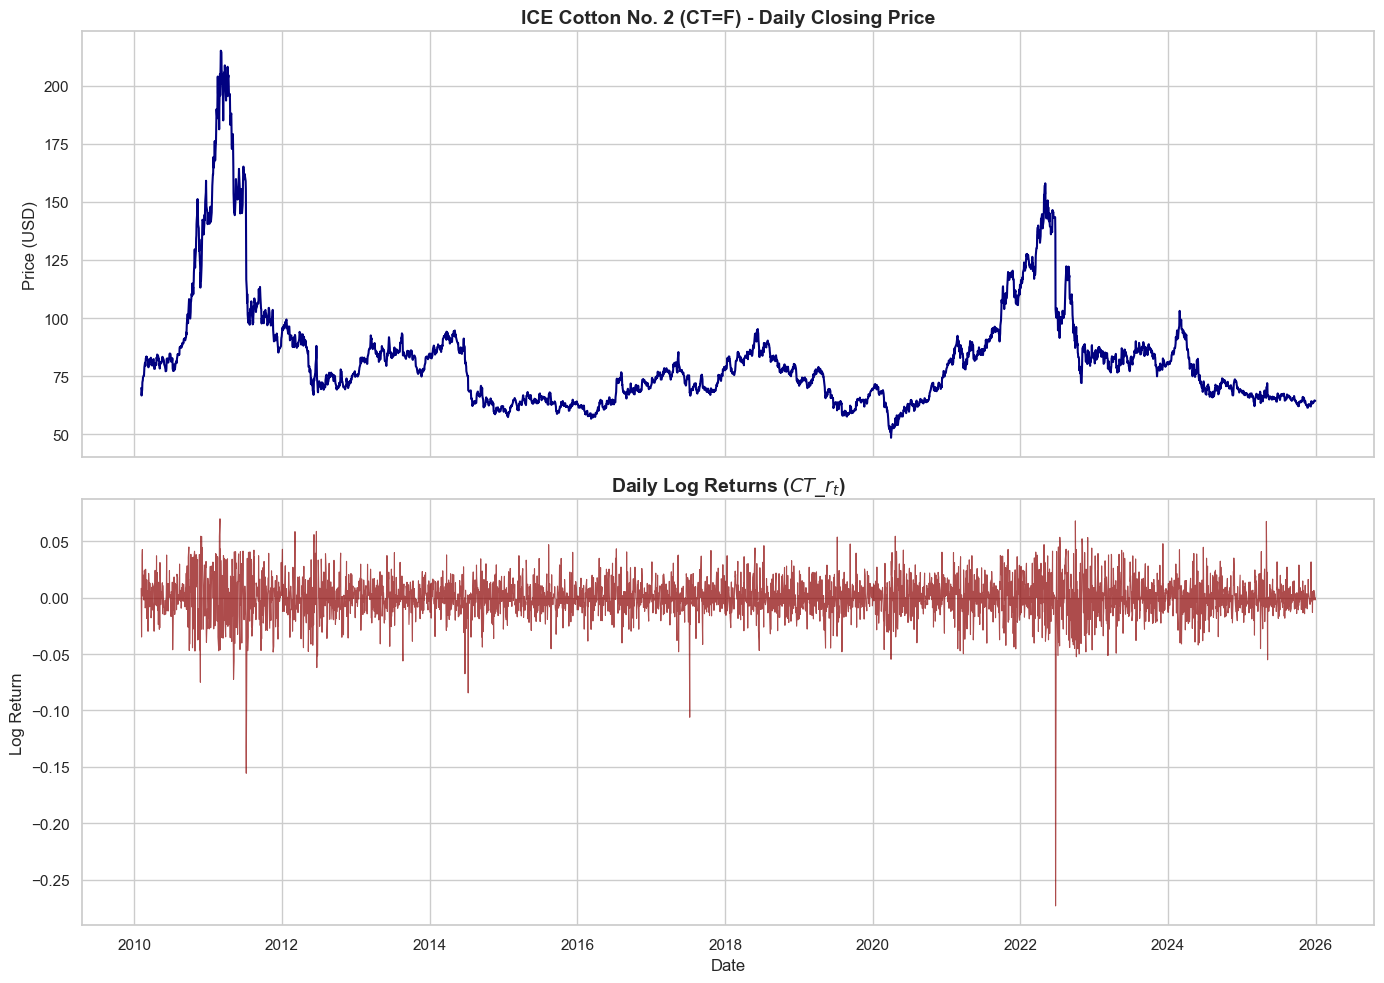


Success! Base engineered dataset saved to: D:\MS_Data_Science_Thesis\Data_Cleaning\Semi_Clean_Datasets\cotton_engineered_I.csv


KeyError: "['Target_Log_Return_t+1'] not in index"

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Directory Setup
base_dir = r"D:\MS_Data_Science_Thesis"
raw_folder = os.path.join(base_dir, "Data_Extraction", "Raw_Data_Folder")
clean_folder = os.path.join(base_dir, "Data_Cleaning", "Semi_Clean_Datasets")

# Create the new directory if it doesn't exist
os.makedirs(clean_folder, exist_ok=True)

input_file = os.path.join(raw_folder, "cotton_futures_raw.csv")

def engineer_cotton_features():
    print("--- Starting Feature Engineering: Cotton Futures Base ---")
    
    if not os.path.exists(input_file):
        print(f"Error: Could not find {input_file}")
        return

    # 2. Load Data
    df = pd.read_csv(input_file)
    
    # Standardize column names (Investing.com vs Yahoo Finance)
    if 'Price' in df.columns and 'Close' not in df.columns:
        df.rename(columns={'Price': 'Close'}, inplace=True)
    if 'Vol.' in df.columns and 'Volume' not in df.columns:
        df.rename(columns={'Vol.': 'Volume'}, inplace=True)
        
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    print("Calculating Log Returns, Volatility, and Momentum indicators...")
    
    # Convert strings with commas to floats (if scraping from Investing.com)
    if df['Close'].dtype == object:
        df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
    
    # 3. Complex Feature Generation
    # Primary Dependent Variable: ln(Price_t / Price_t-1)
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    
    # Handle Open Interest safely
    if 'Open Interest' in df.columns:
        df['Open Interest'] = df['Open Interest'].replace(0, np.nan).ffill()
        df['OI_ROC'] = df['Open Interest'].pct_change()
    else:
        print("Notice: 'Open Interest' column not found. Skipping OI_ROC calculation.")
        
    # Handle Volume safely 
    if 'Volume' in df.columns:
        def clean_volume(x):
            if isinstance(x, str):
                if 'K' in x: return float(x.replace('K', '')) * 1000
                if 'M' in x: return float(x.replace('M', '')) * 1000000
                if '-' in x: return np.nan
            return float(x)
            
        df['Volume'] = df['Volume'].apply(clean_volume)
        df['Vol_10_SMA'] = df['Volume'].rolling(window=10).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Vol_10_SMA']
    
    # 21-Day Annualized Historical Volatility
    df['Volatility_21d'] = df['Log_Return'].rolling(window=21).std() * np.sqrt(252)
    
    # 14-Day RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    # 4. Clean Data
    df_cleaned = df.dropna(subset=['Volatility_21d', 'RSI_14']).copy()
    
    # 5. Data Visualization
    print("Generating diagnostic graphs...")
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Top subplot
    ax1.plot(df_cleaned['Date'], df_cleaned['Close'], color='navy', linewidth=1.5)
    ax1.set_title('ICE Cotton No. 2 (CT=F) - Daily Closing Price', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (USD)', fontsize=12)
    
    # Bottom subplot
    ax2.plot(df_cleaned['Date'], df_cleaned['Log_Return'], color='darkred', linewidth=0.8, alpha=0.7)
    ax2.set_title(r'Daily Log Returns ($CT\_r_t$)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Log Return', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # 6. Export the intermediate dataset
    output_path = os.path.join(clean_folder, "cotton_engineered_I.csv")
    df_cleaned.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Base engineered dataset saved to: {output_path}")
    
    cols_to_show = ['Date', 'Close', 'Log_Return', 'Target_Log_Return_t+1']
    if 'OI_ROC' in df_cleaned.columns: cols_to_show.append('OI_ROC')
    if 'Volume_Ratio' in df_cleaned.columns: cols_to_show.append('Volume_Ratio')
        
    print(df_cleaned[cols_to_show].tail())

if __name__ == "__main__":
    engineer_cotton_features()